# Personalized Article Recommendation System

This notebook builds popularity, user-user collaborative, content-based, and SVD recommenders for IBM Watson Studio articles.

The core evaluation is **leave-one-out ranking on unseen interactions**: one article is removed from each of 1,000 sampled eligible users before any interaction-based model is fit. Recall@K asks whether the recommender recovers that hidden article; NDCG@K also rewards placing it near the top.

This replaces the earlier reconstruction RMSE and full-history scoring, which evaluated interactions the models had already seen.

In [1]:
import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError('Run this notebook from the repository root or notebooks directory.')
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_interactions, load_articles, compute_interaction_stats, create_user_item_matrix, get_sparsity
from src.database import create_database, run_query, QUERIES
from src.rank_recommender import get_top_articles, get_top_article_ids, get_popular_unseen, recommendation_coverage
from src.collaborative import user_user_recs, evaluate_collaborative
from src.content_based import (
    create_content_matrix,
    create_content_similarity,
    find_similar_articles,
    get_user_content_recs,
    evaluate_content_recommendations,
)
from src.matrix_factorization import compute_svd, explained_variance_ratio, variance_thresholds, evaluate_svd
from src.evaluation import evaluate_holdout, leave_one_out_split

sns.set_palette('husl')
%matplotlib inline
np.random.seed(42)

/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## 1. Data Loading & Overview

In [2]:
df = load_interactions()
df_content = load_articles()

print(f'Interactions shape: {df.shape}')
print(f'Articles shape:     {df_content.shape}')
display(df.head())

Interactions shape: (45993, 3)
Articles shape:     (1051, 5)


,article_id,title,email
0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


In [3]:
stats = compute_interaction_stats(df)
for k, v in stats.items():
    print(f'{k:30s}: {v}')

total_interactions            : 45993
unique_users                  : 5148
unique_articles               : 714
avg_interactions              : 8.93
median_interactions           : 3.0
max_interactions              : 364


## 2. SQL-Based Exploration

Before diving into Python-based analysis, we query the data using SQL to demonstrate relational analytics. The data is loaded into a SQLite database with proper schema and indexing.

In [4]:
db_path = create_database(df, df_content)
print(f'Database created at: {db_path}')

Database created at: /Users/tobibolu/Documents/Claude/Projects/Path to AI Engineer/Personal Data Projects/Personalized-Article-Recommendation-System/data/recommendations.db


In [5]:
# Top articles by unique user reach (SQL with JOIN + GROUP BY)
top_articles_sql = run_query(QUERIES['top_articles_by_unique_users'])
display(top_articles_sql)

,article_id,title,unique_users,total_interactions
0,1330,None,467,927
1,1429,None,397,937
2,1364,None,388,627
3,1314,None,345,614
4,1398,None,329,465
5,1431,None,320,671
6,1271,None,314,473
7,1427,None,308,643
8,43,Deep Learning With Tensorflow Course by Big Da...,299,460
9,1160,None,299,433


In [6]:
# User engagement tiers (SQL with CTEs + CASE)
engagement_tiers = run_query(QUERIES['user_engagement_tiers'])
display(engagement_tiers)

,engagement_tier,user_count,avg_interactions
0,1 (one-time),1416,1.0
1,2-5 (casual),1807,3.1
2,6-20 (regular),1365,10.5
3,21-50 (active),425,31.2
4,50+ (power user),136,84.0


In [7]:
# Interaction percentiles (SQL with window functions: NTILE)
percentiles = run_query(QUERIES['interaction_percentiles'])
display(percentiles)

,quartile,min_interactions,max_interactions,avg_interactions,user_count
0,1,1,1,1.0,1288
1,2,1,3,2.3,1287
2,3,3,9,5.7,1287
3,4,9,364,26.7,1287


## 3. Exploratory Data Analysis

The interaction data follows a classic long-tail distribution: most users read only a few articles, while a small number of power users drive a disproportionate share of interactions.

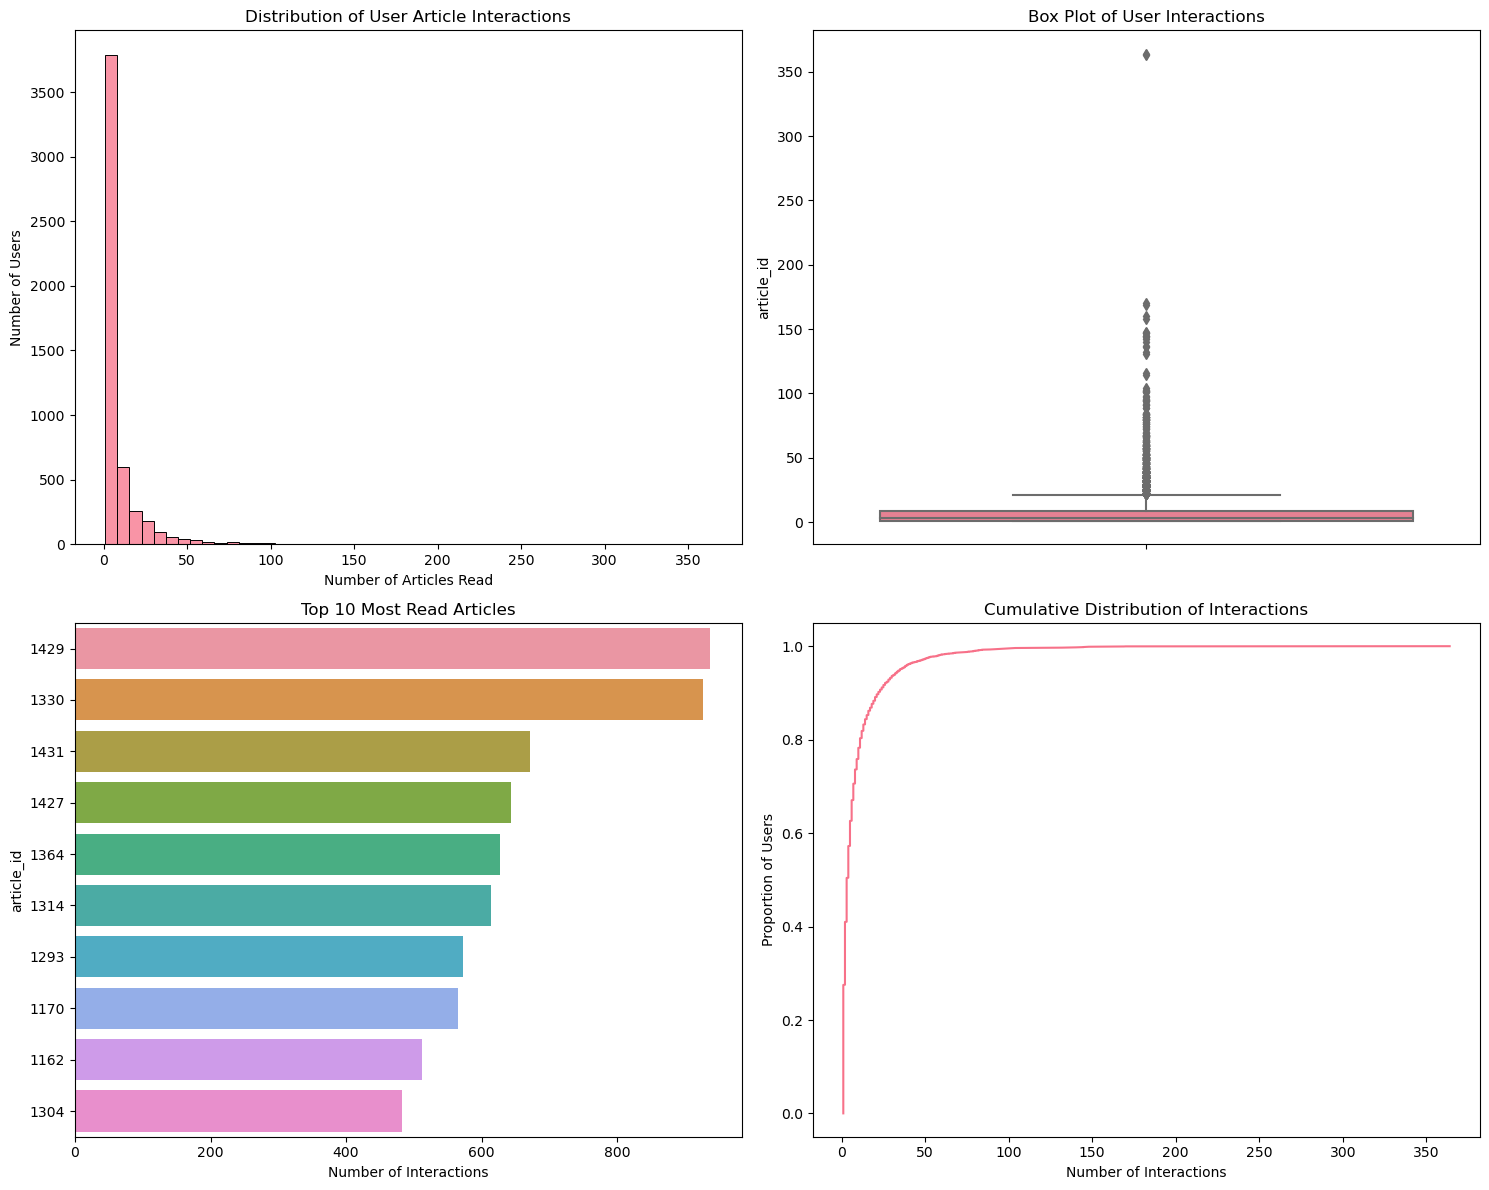

In [8]:
interactions_per_user = df.groupby('email')['article_id'].count()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(data=interactions_per_user, bins=50, ax=ax1)
ax1.set_title('Distribution of User Article Interactions')
ax1.set_xlabel('Number of Articles Read')
ax1.set_ylabel('Number of Users')

sns.boxplot(y=interactions_per_user, ax=ax2)
ax2.set_title('Box Plot of User Interactions')

top_10 = df['article_id'].value_counts().head(10)
sns.barplot(x=top_10.values, y=top_10.index.astype(str), ax=ax3)
ax3.set_title('Top 10 Most Read Articles')
ax3.set_xlabel('Number of Interactions')

sorted_int = np.sort(interactions_per_user)
cumulative = np.arange(1, len(sorted_int)+1) / len(sorted_int)
ax4.plot(sorted_int, cumulative)
ax4.set_title('Cumulative Distribution of Interactions')
ax4.set_xlabel('Number of Interactions')
ax4.set_ylabel('Proportion of Users')

plt.tight_layout()
plt.show()

## 4. Rank-Based Recommendations (Baseline)

The simplest approach: recommend the most popular articles to everyone. This works well for cold-start users but offers no personalization.

In [9]:
print('Top 10 articles by popularity:')
for i, title in enumerate(get_top_articles(df, 10), 1):
    print(f'  {i:2d}. {title}')

print()
cov = recommendation_coverage(df, 10)
for k, v in cov.items():
    print(f'{k}: {v}')

Top 10 articles by popularity:
   1. use deep learning for image classification
   2. insights from new york car accident reports
   3. visualize car data with brunel
   4. use xgboost, scikit-learn & ibm watson machine learning apis
   5. predicting churn with the spss random tree algorithm
   6. healthcare python streaming application demo
   7. finding optimal locations of new store using decision optimization
   8. apache spark lab, part 1: basic concepts
   9. analyze energy consumption in buildings
  10. gosales transactions for logistic regression model

n_recommended: 10
total_articles: 714
pct_articles: 1.4
pct_interactions: 14.24


The top 10 articles represent only 1.4% of the catalog but account for 14.2% of all interactions, confirming the popularity concentration.

## 5. User-User Collaborative Filtering

Recommends articles based on what similar users have read. The user-item matrix is extremely sparse (99%+), which limits the effectiveness of this approach.

In [10]:
user_item = create_user_item_matrix(df)
sparsity = get_sparsity(user_item)
print(f'User-item matrix: {user_item.shape[0]} users x {user_item.shape[1]} articles')
print(f'Sparsity: {sparsity:.2f}%')

User-item matrix: 5148 users x 714 articles
Sparsity: 99.08%


In [11]:
# This is a system diagnostic, not an accuracy metric. It checks whether the
# collaborative method can produce a full list and how much neighbour support
# those recommendations receive. Prospective ranking quality is tested later.
cf_diagnostic = evaluate_collaborative(user_item, sample_size=100)
print('Collaborative-filtering availability diagnostic:')
for key, value in cf_diagnostic.items():
    print(f'  {key}: {value}')

Collaborative-filtering availability diagnostic:
  avg_recommendations: 10.0
  avg_similarity_score: 0.3362


## 6. Content-Based Recommendations

Uses TF-IDF on article titles and descriptions to find similar articles. This approach doesn't require user history and addresses the cold-start problem for new articles.

In [12]:
# Mean cosine similarity describes semantic closeness; it does not tell us
# whether users wanted the recommendations. Unseen-interaction ranking is
# evaluated on the same holdout as the other methods in Section 8.
content_diagnostic = evaluate_content_recommendations(df_content, sample_size=100)
print('Content-similarity diagnostic:')
for key, value in content_diagnostic.items():
    print(f'  {key}: {value}')

Content-similarity diagnostic:
  avg_similarity: 0.319
  median_similarity: 0.256


In [13]:
# Example: find a popular article that has content metadata for similarity demo
content_matrix, _ = create_content_matrix(df_content)
content_article_ids = set(df_content['article_id'].values)
top_ids = get_top_article_ids(df, 50)
demo_id = next(aid for aid in top_ids if int(aid) in content_article_ids)

similar = find_similar_articles(demo_id, df_content, content_matrix, n=5)
title = df[df.article_id == demo_id].title.iloc[0]
print(f'Articles similar to "{title}":')
for _, row in similar.iterrows():
    print(f'  - {row.doc_full_name} (similarity: {row.similarity_score:.3f})')

Articles similar to "deep learning with tensorflow course by big data university":
  - Learn TensorFlow and Deep Learning Together and Now! (similarity: 0.521)
  - Perform sentiment analysis with LSTMs, using TensorFlow (similarity: 0.356)
  - TensorFlow Quick Tips (similarity: 0.349)
  - Deep Learning with Data Science Experience (similarity: 0.239)
  - Deep Learning From Scratch I: Computational Graphs (similarity: 0.227)


## 7. Leakage-Safe Leave-One-Out Evaluation

### Why the earlier evaluation was invalid

Reconstruction RMSE measured how closely SVD reproduced the same binary matrix used for factorisation. Because roughly 99% of that matrix is zero, a low RMSE can be achieved without ranking useful unseen articles. The earlier `evaluate_recommendations` function also compared recommendations with each user's **full visible history**; despite its name, it did not remove an interaction.

The corrected protocol is:

1. Start with the binary user-item matrix.
2. Keep users with at least two unique article interactions.
3. Reproducibly sample 1,000 eligible users and hide one article from each.
4. Train/generate every interaction-based recommendation from the reduced matrix.
5. Score the ordered recommendations against only the hidden article.

With one hidden article, Recall@K is also Hit Rate@K. NDCG@K gives more credit when the hidden article appears nearer rank 1.

Eligible users (2+ unique articles): 3,591
Evaluated users: 1,000
One hidden article removed from every evaluated user: True
Visible interactions removed: 1,000



Training-matrix variance thresholds:
  50pct: 60 components
  80pct: 180 components
  90pct: 274 components


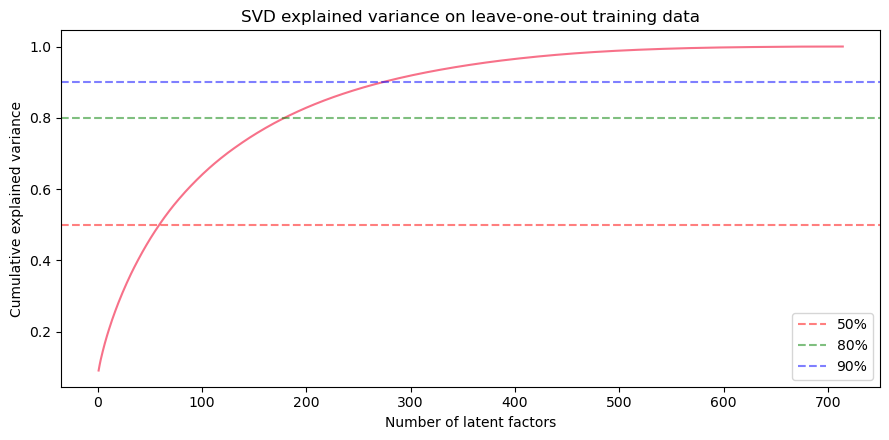

In [14]:
EVALUATION_SEED = 42
EVALUATION_USERS = 1000

train_user_item, holdout = leave_one_out_split(
    user_item,
    min_interactions=2,
    seed=EVALUATION_SEED,
    sample_size=EVALUATION_USERS,
)

eligible_users = int((user_item.sum(axis=1) >= 2).sum())
removed_cells_are_zero = all(
    train_user_item.loc[user_id, next(iter(relevant))] == 0
    for user_id, relevant in holdout.items()
)
print(f'Eligible users (2+ unique articles): {eligible_users:,}')
print(f'Evaluated users: {len(holdout):,}')
print(f'One hidden article removed from every evaluated user: {removed_cells_are_zero}')
print(f'Visible interactions removed: {int(user_item.values.sum() - train_user_item.values.sum()):,}')

# Factorise only the reduced training matrix for diagnostics.
U_train, s_train, Vt_train = compute_svd(train_user_item)
thresholds = variance_thresholds(s_train)
print('\nTraining-matrix variance thresholds:')
for label, components in thresholds.items():
    print(f'  {label}: {components} components')

evr = explained_variance_ratio(s_train)
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, len(evr) + 1), evr)
for level, color in [(0.5, 'r'), (0.8, 'g'), (0.9, 'b')]:
    plt.axhline(level, color=color, linestyle='--', alpha=0.5, label=f'{level:.0%}')
plt.xlabel('Number of latent factors')
plt.ylabel('Cumulative explained variance')
plt.title('SVD explained variance on leave-one-out training data')
plt.legend()
plt.tight_layout()
plt.show()

,n_factors,n_evaluated,precision@5,precision@10,recall@5,recall@10,ndcg@5,ndcg@10
0,10,1000,0.0248,0.0179,0.124,0.179,0.0815,0.0990
1,20,1000,0.0252,0.0189,0.126,0.189,0.0880,0.1082
2,50,1000,0.0248,0.0192,0.124,0.192,0.0877,0.1096
3,100,1000,0.0222,0.0154,0.111,0.154,0.0816,0.0957


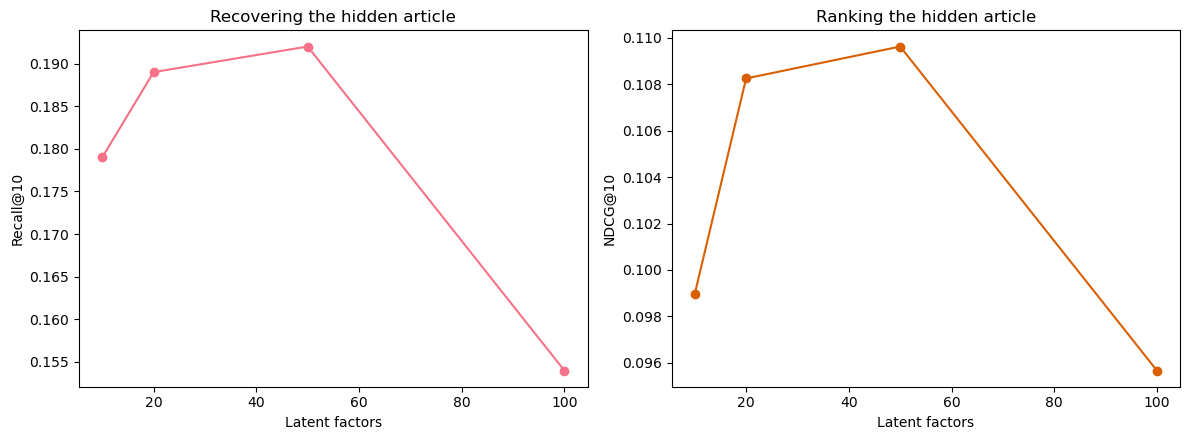

In [15]:
svd_results = evaluate_svd(
    train_user_item,
    holdout,
    n_factors_list=[10, 20, 50, 100],
    k_values=(5, 10),
)
display(svd_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(svd_results['n_factors'], svd_results['recall@10'], marker='o')
axes[0].set(xlabel='Latent factors', ylabel='Recall@10', title='Recovering the hidden article')
axes[1].plot(svd_results['n_factors'], svd_results['ndcg@10'], marker='o', color='#d95f02')
axes[1].set(xlabel='Latent factors', ylabel='NDCG@10', title='Ranking the hidden article')
plt.tight_layout()
plt.show()

## 8. Fair Method Comparison

Every method below receives the same reduced training matrix and is scored against the same 1,000 hidden interactions.

- **Popularity** is the non-personalised baseline and excludes each user's visible history.
- **User-user CF** ranks unseen articles by similarity-weighted neighbour support.
- **Content-based** ranks unseen articles by mean TF-IDF cosine similarity to the user's visible history.
- **SVD** is factorised on the reduced matrix; the factor count is selected by Recall@10/NDCG@10, not reconstruction error.

These are offline ranking metrics. They support choosing an experiment candidate, not claiming real engagement lift.

,n_evaluated,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
Popularity,1000.0,0.0122,0.061,0.0342,0.0104,0.104,0.0480
User-user CF,1000.0,0.0204,0.102,0.0714,0.0154,0.154,0.0881
Content-based,1000.0,0.0030,0.015,0.0099,0.0027,0.027,0.0137
SVD (k=50),1000.0,0.0248,0.124,0.0877,0.0192,0.192,0.1096


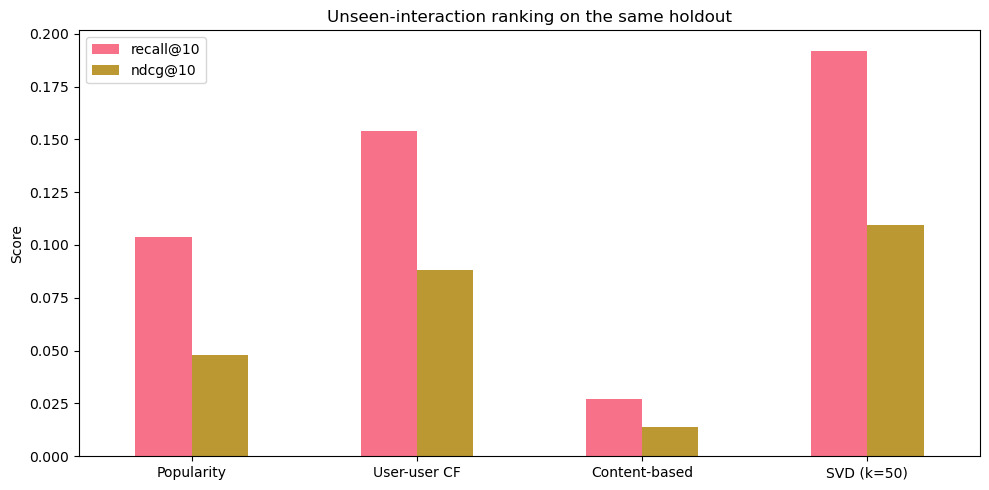

Wrote evaluation_metrics.json


In [16]:
popularity_metrics = evaluate_holdout(
    holdout,
    recommend_fn=lambda user_id, n: get_popular_unseen(user_id, train_user_item, n),
    k_values=(5, 10),
)

collaborative_metrics = evaluate_holdout(
    holdout,
    recommend_fn=lambda user_id, n: user_user_recs(user_id, train_user_item, m=n),
    k_values=(5, 10),
)

content_matrix, _ = create_content_matrix(df_content)
content_similarity = create_content_similarity(content_matrix)
content_metrics = evaluate_holdout(
    holdout,
    recommend_fn=lambda user_id, n: get_user_content_recs(
        user_id, train_user_item, df_content, content_similarity, n
    ),
    k_values=(5, 10),
)

best_svd_row = svd_results.loc[svd_results['recall@10'].idxmax()]
best_svd_factors = int(best_svd_row['n_factors'])
metric_columns = ['n_evaluated', 'precision@5', 'recall@5', 'ndcg@5', 'precision@10', 'recall@10', 'ndcg@10']

comparison = pd.DataFrame({
    'Popularity': popularity_metrics,
    'User-user CF': collaborative_metrics,
    'Content-based': content_metrics,
    f'SVD (k={best_svd_factors})': best_svd_row.to_dict(),
}).T[metric_columns]

display(comparison.round(4))

ax = comparison[['recall@10', 'ndcg@10']].plot(kind='bar', figsize=(10, 5), rot=0)
ax.set(title='Unseen-interaction ranking on the same holdout', ylabel='Score')
plt.tight_layout()
plt.show()

artifact = {
    'protocol': {
        'type': 'leave-one-out unseen-interaction ranking',
        'eligible_users': eligible_users,
        'evaluated_users': len(holdout),
        'minimum_unique_interactions': 2,
        'hidden_interactions_per_user': 1,
        'seed': EVALUATION_SEED,
    },
    'best_svd_factors_by_recall_at_10': best_svd_factors,
    'methods': json.loads(comparison.to_json(orient='index')),
}
(PROJECT_ROOT / 'evaluation_metrics.json').write_text(json.dumps(artifact, indent=2) + '\n')
print('Wrote evaluation_metrics.json')

## 9. Conclusions

The honest offline result is narrower—and much more useful—than the previous RMSE claim:

| Method | Recall@10 | NDCG@10 | Reading |
|---|---:|---:|---|
| Popularity | 0.104 | 0.048 | Strong cold-start floor, but no personalisation |
| User-user CF | 0.154 | 0.088 | Similar-user history improves on popularity |
| Content-based | 0.027 | 0.014 | TF-IDF text alone is weak for recovering user interactions |
| SVD (50 factors) | **0.192** | **0.110** | Best offline ranking on this fixed holdout |

SVD with 50 factors recovers 19.2% of hidden articles within ten recommendations, versus 10.4% for popularity. That is an **8.8 percentage-point offline lift in Recall@10**, not proof of product engagement or revenue impact. Absolute recall remains modest, so the defensible recommendation is to A/B test SVD for returning users while retaining popularity for cold-start users.

### Next steps

- Repeat the split across several random seeds and report confidence intervals.
- Add time-aware evaluation if interaction timestamps become available; random leave-one-out cannot test temporal drift.
- Tune a hybrid using validation splits, keeping the final test split untouched.
- Track catalog coverage and novelty alongside relevance so popular articles do not dominate every list.
- Run an online experiment with a pre-declared primary metric such as article-open rate or qualified reading time.

The key lesson is the same as supervised model validation: **the interaction being predicted must be hidden before training, and the metric must match the ranked decision the product actually makes.**